In [17]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *

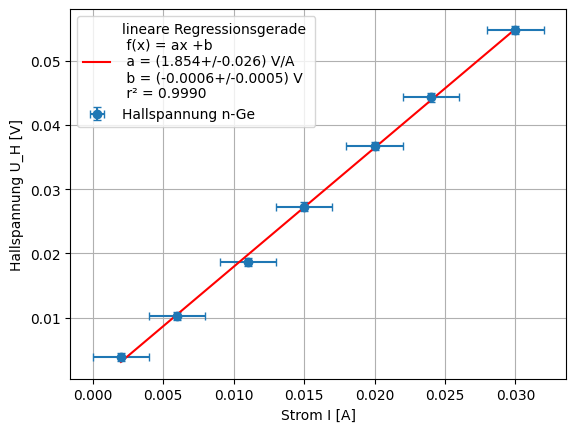

Hallkonstante R_H: (1.236+/-0.020)e-05 [m³/C] = 12.36+/-0.20 [cm³/C]
Ladungskonzentration n: (-5.06+/-0.08)e+23 [1/m³]  = (-5.06+/-0.08)e+17 [1/cm³]



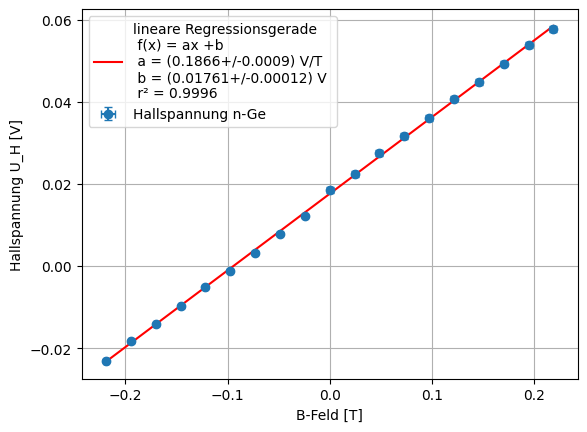

Hallkonstante R_H: 0.0075+/-0.0006 [m³/C] = (7.5+/-0.6)e+03 [cm³/C]
Ladungsträgerdichte n: (-8.4+/-0.7)e+20 [1/m³] = (-8.4+/-0.7)e+14 [1/cm³]



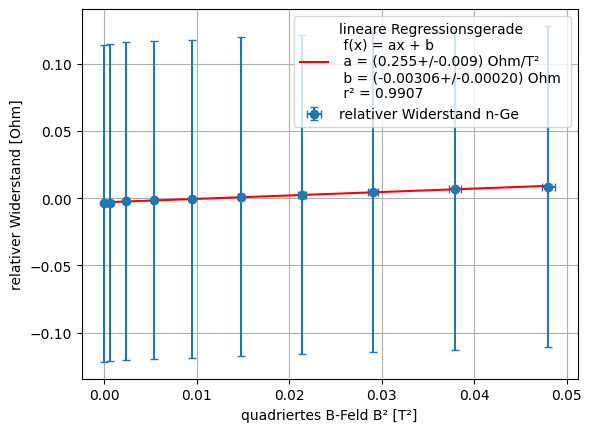

spezifischer Widerstand rho: 0.0185+/-0.0026 [Ohm m] = 1.85+/-0.26 [Ohm cm]
Leitfähigkeit sigma_n: 54+/-8 [1/(Ohm m)] = 0.54+/-0.08 [1/(Ohm cm)]

Beweglichkeit mu_n: -0.40+/-0.05 [m²/(Vs)] = (-4.0+/-0.5)e+03 [cm²/(Vs)]


In [18]:
# Hallspannung (Aufgaben 1-5)

#bekannte Werte und wichtige Größen:
e = 1.6 * 10**(-19)         #[C = As]; Elementarladung

l = 0.02               #[m]; Abmessungen der Probe
b = 0.01               #[m]
d = 0.001              #[m]

A = b * d           #[m²]; Querschnitt der Probe

d_p = ufloat(1, 0.02)       #[cm]; Abstand Polschuhe

def B(I_b, u = False):
    """zur Berechnung von B nach Stromstärke I_b.
    Entweder mit unsicherheit oder ohne
    
    [I_b] = A
    [B] = mT"""

    if u == True:
        B = ufloat(48.7, 0.25) * I_b
    else:
        B = 48.7 * I_b

    return B

B_faktor = ufloat(48.7, 0.25)


#1. U_H als Fkt von I
I_b = ufloat(3.079, 3.1*0.005+0.003)             #Strom zum Betreiben des Magneten [A]
B = B(I_b, u=True)              #Magnetfeld [mT]; sollte ca 150 sein

I_probe = unp.uarray([30, 24, 20, 15, 11, 6, 2], 2)/1000       #gemessener Probenstrom [mA --> A]; 6 Werte zwischen 2 und 30 mA
U_H = unp.uarray([54.8, 44.3, 36.7, 27.3, 18.7, 10.2, 3.8], 54.8*0.01+0.1)/1000          #Hallspannung [V]

I_nom = unp.nominal_values(I_probe)   #nominalwerte für fit; [A]
I_u = unp.std_devs(I_probe)           #Unsicherheiten für fit; [A]

U_H_nom = unp.nominal_values(U_H)       #nominalwerte für fit; [V]  
U_H_u = unp.std_devs(U_H)               #Unsicherheiten für fit; [V]

reg1 = linregress(I_nom, U_H_nom)
a = ufloat(reg1.slope, reg1.stderr)         #Steigung aus Fit [V/A] a = R_H * B / d mit R_H = - 1/(ne) 
b = ufloat(reg1.intercept, reg1.intercept_stderr)       #Achsenabschnitt [V]

I_plot = np.linspace(min(I_nom), max(I_nom), 200)       #kontinuierliche werte für plot der fitgeraden

plt.figure()
plt.errorbar(I_nom, U_H_nom, xerr=I_u, yerr=U_H_u, capsize=3, fmt='o', label="Hallspannung n-Ge")
plt.plot(I_plot, I_plot*reg1.slope + reg1.intercept, '-r', label=f"lineare Regressionsgerade \n f(x) = ax +b \n a = ({a}) V/A \n b = ({b}) V \n r² = {reg1.rvalue**2:.4f}")
plt.xlabel("Strom I [A]")
plt.ylabel("Hallspannung U_H [V]")
plt.legend()
plt.grid(True)
plt.show()

R_H = (a * d) / B           #Hallkonstante aus Fit berechnet [m³/C]; für literaturvergleich noch umrechnen!
n = - 1 / (R_H * e)         #Ladungsdichte [1/m³]

R_H_cm = R_H * (10**2)**3
n_cm = - 1 / (R_H_cm * e)

print(f"Hallkonstante R_H: {R_H} [m³/C] = {R_H_cm} [cm³/C]")
print(f"Ladungskonzentration n: {n} [1/m³]  = {n_cm} [1/cm³]")
print()


#2. U_H und U_L als Fkt von B
I_probe = ufloat(0.025, 0.002)         #konstanter Probenstrom [A]; bleibt ab jetzt so!!

I_b = unp.uarray([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5], 4.5*0.005+0.003)      #strom zum betreiben des Magenten [A], in 0.5A Schritten bis 4.5A
B = I_b * B_faktor / 1000          #B-Feld aus Strom I_b [T]


U_H = unp.uarray([18.5, 22.5, 27.5, 31.7, 36.1, 40.8, 44.9, 49.3, 53.8, 57.7], 57.7*0.01+0.1)/1000      #Hallspannung [V]
U_L = unp.uarray([919, 920, 921, 921, 922, 924, 925, 927, 928, 930], 930*0.01+0.1)/1000      #Längsspannugn [V]

B_nom = unp.nominal_values(B)       #nominalwerte für fit; [T]  
B_u = unp.std_devs(B)               #Unsicherheiten für fit; [T]

U_H_nom = unp.nominal_values(U_H)       #nominalwerte für fit; [V]  
U_H_u = unp.std_devs(U_H)               #Unsicherheiten für fit; [V]

U_L_nom = unp.nominal_values(U_L)       #nominalwerte für fit; [V]  
U_L_u = unp.std_devs(U_L)               #Unsicherheiten für fit; [V]


#3. U_H und U_L als Fkt vom umgepolten Magnetfeld B_pol
I_probe = ufloat(0.025, 0.002)         #konstanter Probenstrom [A]; bleibt ab jetzt so!!

I_b = unp.uarray([-0.5, -1, -1.5, -2, -2.5, -3, -3.5, -4, -4.5], 0.0255)      #strom zum betreiben des Magenten [A], in 0.5A Schritten bis -4.5A; jetzt negative Werte
B_pol = I_b * B_faktor /1000          #B-Feld aus Strom I_b [T]; soltte jetzt negativ sein


U_H_pol = unp.uarray([12.2, 7.9, 3.3, -1.1, -5.2, -9.8, -14.2, -18.3, -23], 23*0.01+0.1)/1000      #Hallspannung bei umgepolten Magnetfeld [V]
U_L_pol = unp.uarray([922, 922, 923, 924, 925, 926, 928, 930, 932, 934], 934*0.01+0.1)/1000      #Längsspannugn bei umgepolten Magnetfeld[V]; AUCH DEN WERT FÜR 0 EINTRAGEN (--> Aufgabe 5)

B_pol_nom = unp.nominal_values(B_pol)       #nominalwerte für fit; [T]  
B_pol_u = unp.std_devs(B_pol)               #Unsicherheiten für fit; [T]

U_H_pol_nom = unp.nominal_values(U_H_pol)       #nominalwerte für fit; [V]  
U_H_pol_u = unp.std_devs(U_H_pol)               #Unsicherheiten für fit; [V]

U_L_pol_nom = unp.nominal_values(U_L_pol)       #nominalwerte für fit; [V]  
U_L_pol_u = unp.std_devs(U_L_pol)               #Unsicherheiten für fit; [V]


#4. U_H Werte Zusammenfügen und gegen B plotten

B_ges = np.concatenate([B_pol, B])           #Aus den Werten von B ein uarray machen [T]

B_ges_nom = unp.nominal_values(B_ges)        #nominalwerte und Unsicherheit B [T]
B_ges_u = unp.std_devs(B_ges)

U_H_ges = np.concatenate([U_H_pol, U_H])        #Aus Werten von U_H ein uarray machen [V]

U_H_ges_nom = unp.nominal_values(U_H_ges)       #nominalwerte und Unsicherheit Hallspannung [V]
U_H_ges_u = unp.std_devs(U_H_ges)

reg_hall = linregress(B_ges_nom, U_H_ges_nom)           #lineare Regression Hallspannung
a_hall = ufloat(reg_hall.slope, reg_hall.stderr)                    #Steigung aus fit [V/T]; a_hall = R_H * I / d
b_hall = ufloat(reg_hall.intercept, reg_hall.intercept_stderr)      #Achsenabschnitt aus Fit [V]

B_plot = np.linspace(min(B_ges_nom), max(B_ges_nom), 200)

plt.figure()
plt.errorbar(B_ges_nom, U_H_ges_nom, xerr=B_ges_u, yerr=U_H_ges_u, capsize=3, fmt='o', label="Hallspannung n-Ge")
plt.plot(B_plot, B_plot*reg_hall.slope + reg_hall.intercept, '-r', label=f"lineare Regressionsgerade \n f(x) = ax +b \n a = ({a_hall}) V/T \n b = ({b_hall}) V \n r² = {reg_hall.rvalue**2:.4f}")
plt.xlabel("B-Feld [T]")
plt.ylabel("Hallspannung U_H [V]")
plt.legend()
plt.grid(True)
plt.show()

R_H = (a_hall * d) / I_probe        #Hallkonstante [m³/C]
n = -1 / (R_H * e)                  #Ladungstragerdichte [1/m³]

R_H_cm = R_H * (10**2)**3
n_cm = -1 / (R_H_cm * e)

print(f"Hallkonstante R_H: {R_H} [m³/C] = {R_H_cm} [cm³/C]")
print(f"Ladungsträgerdichte n: {n} [1/m³] = {n_cm} [1/cm³]")
print()


#5. relative Widerstandsänderung aus U_L
U_L_ges = (U_L_pol + U_L)/2         #mitteln der Längsspanung bei verschiedenen Polungen des Magnetfelds [V]
U0 = ufloat(0.924, 0.924*0.01+0.1)             #Wert U(0); Längsspannugn wenn Magnetfeld nicht betrieben --> ablesen, [V]

R_B = U_L_ges / I_probe     #Widerstand abhängig vom Magnetfeld [Ohm]
R0 = U0 / I_probe           #Widerstand bei Magnetfeld 0 [Ohm]

R_rel = (R_B - R0) / R0     #relative Widerstandsänderung; einheitslos

R_rel_nom = unp.nominal_values(R_rel)
R_rel_u = unp.std_devs(R_rel)

B2 = B**2                   #B Feld quadriert (relative Widerstandsänderung ist proportional dazu ?) [T²]

B2_nom = unp.nominal_values(B2)
B2_u = unp.std_devs(B2)

reg_rel = linregress(B2_nom, R_rel_nom)         #lineare Regression für zusammenhang Widerstandsänderung und Magnetfeld
a_rel = ufloat(reg_rel.slope, reg_rel.stderr)           #Steigung [Ohm/T²]
b_rel = ufloat(reg_rel.intercept, reg_rel.intercept_stderr)     #Achsenabschnitt [Ohm]

B2_plot = np.linspace(min(B2_nom), max(B2_nom), 200)

plt.figure()
plt.errorbar(B2_nom, R_rel_nom, xerr=B2_u, yerr=R_rel_u, capsize=3, fmt='o', label="relativer Widerstand n-Ge")
plt.plot(B2_plot, B2_plot*reg_rel.slope + reg_rel.intercept, '-r', label=f"lineare Regressionsgerade \n f(x) = ax + b \n a = ({a_rel}) Ohm/T² \n b = ({b_rel}) Ohm \n r² = {reg_rel.rvalue**2:.4f}")
plt.xlabel("quadriertes B-Feld B² [T²]")
plt.ylabel("relativer Widerstand [Ohm]")
plt.legend()
plt.grid(True)
plt.show()

rho = (R0 * A) / l              #spezifischer Widerstand [Ohm m]
sigma_n = 1 / rho                 #Leitfähigkeit [1 /(Ohm m)]

rho_cm = rho * 10**2
sigma_n_cm = 1 / rho_cm

print(f"spezifischer Widerstand rho: {rho} [Ohm m] = {rho_cm} [Ohm cm]")
print(f"Leitfähigkeit sigma_n: {sigma_n} [1/(Ohm m)] = {sigma_n_cm} [1/(Ohm cm)]")
print()

mu_n = sigma_n / (n * e)        #Beweglichkeit [m²/(Vs)]
mu_n_cm = sigma_n_cm / (n_cm * e)

print(f"Beweglichkeit mu_n: {mu_n} [m²/(Vs)] = {mu_n_cm} [cm²/(Vs)]")




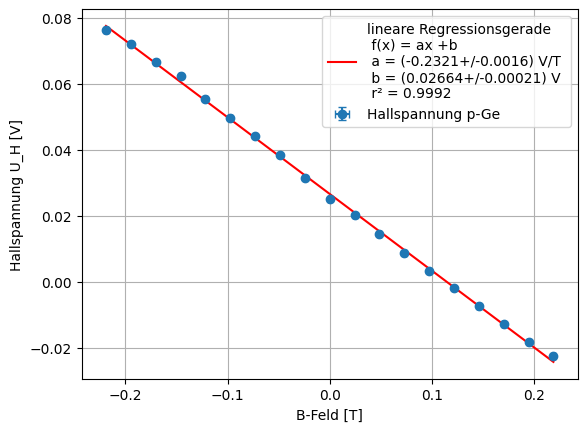

Hallkonstante R_H: -0.0093+/-0.0007 [m³/C] = (-9.3+/-0.7)e+03 [cm³/C]
Ladungsträgerdichte p: (6.7+/-0.5)e+20 [1/m³] = (6.7+/-0.5)e+14 [1/cm³]



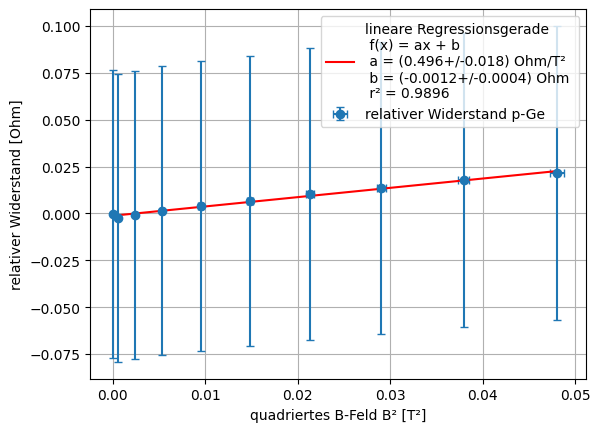

spezifischer Widerstand rho: 0.0279+/-0.0031 [Ohm m] = 2.79+/-0.31 [Ohm cm]
Leitfähigkeit sigma_p: 36+/-4 [1/(Ohm m)] = 0.36+/-0.04 [1/(Ohm cm)]

Beweglichkeit mu_p: 0.333+/-0.026 [m²/(Vs)] = (3.33+/-0.26)e+03 [cm²/(Vs)]


In [19]:
#p-Ge (Aufgabe 6; wie 2-5 oben)

#2. U_H und U_L als Fkt von B
I_probe = ufloat(0.025, 0.002)         #konstanter Probenstrom [A]; bleibt ab jetzt so!!

I_b = unp.uarray([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5], 4.5*0.005+0.003)      #strom zum betreiben des Magenten [A], in 0.5A Schritten bis 4.5A
B = I_b * B_faktor / 1000          #B-Feld aus Strom I_b [T]

U_H = unp.uarray([25.2, 20.4, 14.5, 8.7, 3.2, -1.7, -7.2, -12.7, -18.3, -22.5], 25.2*0.008*0.3)/1000      #Hallspannung [V]
U_L = unp.uarray([1.393, 1.386, 1.389, 1.393, 1.397, 1.401, 1.406, 1.411, 1.418, 1.423], 1.423*0.005+0.001)      #Längsspannugn [V]

B_nom = unp.nominal_values(B)       #nominalwerte für fit; [T]  
B_u = unp.std_devs(B)               #Unsicherheiten für fit; [T]

U_H_nom = unp.nominal_values(U_H)       #nominalwerte für fit; [V]  
U_H_u = unp.std_devs(U_H)               #Unsicherheiten für fit; [V]

U_L_nom = unp.nominal_values(U_L)       #nominalwerte für fit; [V]  
U_L_u = unp.std_devs(U_L)               #Unsicherheiten für fit; [V]


#3. U_H und U_L als Fkt vom umgepolten Magnetfeld B_pol
I_probe = ufloat(0.025, 0.002)         #konstanter Probenstrom [A]; bleibt ab jetzt so!!

I_b = unp.uarray([-0.5, -1, -1.5, -2, -2.5, -3, -3.5, -4, -4.5], 4.5*0.005+0.003)      #strom zum betreiben des Magenten [A], in 0.5A Schritten bis -4.5A; jetzt negative Werte
B_pol = I_b * B_faktor / 1000          #B-Feld aus Strom I_b [T]; soltte jetzt negativ sein

U_H_pol = unp.uarray([31.4, 38.5, 44.2, 49.6, 55.4, 62.4, 66.7, 72.0, 76.3], 76.3*0.008*0.3)/1000      #Hallspannung bei umgepolten Magnetfeld [V]
U_L_pol = unp.uarray([1.394, 1.395, 1.397, 1.399, 1.402, 1.405, 1.411, 1.415, 1.420, 1.425], 1.425*0.005+0.001)      #Längsspannugn bei umgepolten Magnetfeld[V]; AUCH DEN WERT FÜR 0 EINTRAGEN (--> Aufgabe 5)

B_pol_nom = unp.nominal_values(B_pol)       #nominalwerte für fit; [T]  
B_pol_u = unp.std_devs(B_pol)               #Unsicherheiten für fit; [T]

U_H_pol_nom = unp.nominal_values(U_H_pol)       #nominalwerte für fit; [V]  
U_H_pol_u = unp.std_devs(U_H_pol)               #Unsicherheiten für fit; [V]

U_L_pol_nom = unp.nominal_values(U_L_pol)       #nominalwerte für fit; [V]  
U_L_pol_u = unp.std_devs(U_L_pol)               #Unsicherheiten für fit; [V]


#4. U_H Werte Zusammenfügen und gegen B plotten

B_ges = np.concatenate([B_pol, B])           #Aus den Werten von B ein uarray machen [T]

B_ges_nom = unp.nominal_values(B_ges)        #nominalwerte und Unsicherheit B [T]
B_ges_u = unp.std_devs(B_ges)

U_H_ges = np.concatenate([U_H_pol, U_H])        #Aus Werten von U_H ein uarray machen [V]

U_H_ges_nom = unp.nominal_values(U_H_ges)       #nominalwerte und Unsicherheit Hallspannung [V]
U_H_ges_u = unp.std_devs(U_H_ges)

reg_hall = linregress(B_ges_nom, U_H_ges_nom)           #lineare Regression Hallspannung
a_hall = ufloat(reg_hall.slope, reg_hall.stderr)                    #Steigung aus fit [V/T]; a_hall = R_H * I / d
b_hall = ufloat(reg_hall.intercept, reg_hall.intercept_stderr)      #Achsenabschnitt aus Fit [V]

B_plot = np.linspace(min(B_ges_nom), max(B_ges_nom), 200)

plt.figure()
plt.errorbar(B_ges_nom, U_H_ges_nom, xerr=B_ges_u, yerr=U_H_ges_u, capsize=3, fmt='o', label="Hallspannung p-Ge")
plt.plot(B_plot, B_plot*reg_hall.slope + reg_hall.intercept, '-r', label=f"lineare Regressionsgerade \n f(x) = ax +b \n a = ({a_hall}) V/T \n b = ({b_hall}) V \n r² = {reg_hall.rvalue**2:.4f}")
plt.xlabel("B-Feld [T]")
plt.ylabel("Hallspannung U_H [V]")
plt.legend()
plt.grid(True)
plt.show()

R_H = (a_hall * d) / I_probe        #Hallkonstante [m³/C]
p = -1 / (R_H * e)                  #Ladungstragerdichte [1/m³]

R_H_cm = R_H * (10**2)**3
p_cm = -1 / (R_H_cm * e)

print(f"Hallkonstante R_H: {R_H} [m³/C] = {R_H_cm} [cm³/C]")
print(f"Ladungsträgerdichte p: {p} [1/m³] = {p_cm} [1/cm³]")
print()


#5. relative Widerstandsänderung aus U_L
U_L_ges = (U_L_pol + U_L)/2         #mitteln der Längsspanung bei verschiedenen Polungen des Magnetfelds [V]
U0 = ufloat(1.394, 1.394*0.005+0.1)             #Wert U(0); Längsspannugn wenn Magnetfeld nicht betrieben --> ablesen, [V]

R_B = U_L_ges / I_probe     #Widerstand abhängig vom Magnetfeld [Ohm]
R0 = U0 / I_probe           #Widerstand bei Magnetfeld 0 [Ohm]

R_rel = (R_B - R0) / R0     #relative Widerstandsänderung; einheitslos

R_rel_nom = unp.nominal_values(R_rel)
R_rel_u = unp.std_devs(R_rel)

B2 = B**2                   #B Feld quadriert (relative Widerstandsänderung ist proportional dazu ?) [T²]

B2_nom = unp.nominal_values(B2)
B2_u = unp.std_devs(B2)

reg_rel = linregress(B2_nom, R_rel_nom)         #lineare Regression für zusammenhang Widerstandsänderung und Magnetfeld
a_rel = ufloat(reg_rel.slope, reg_rel.stderr)           #Steigung [Ohm/T²]
b_rel = ufloat(reg_rel.intercept, reg_rel.intercept_stderr)     #Achsenabschnitt [Ohm]

B2_plot = np.linspace(min(B2_nom), max(B2_nom), 200)

plt.figure()
plt.errorbar(B2_nom, R_rel_nom, xerr=B2_u, yerr=R_rel_u, capsize=3, fmt='o', label="relativer Widerstand p-Ge")
plt.plot(B2_plot, B2_plot*reg_rel.slope + reg_rel.intercept, '-r', label=f"lineare Regressionsgerade \n f(x) = ax + b \n a = ({a_rel}) Ohm/T² \n b = ({b_rel}) Ohm \n r² = {reg_rel.rvalue**2:.4f}")
plt.xlabel("quadriertes B-Feld B² [T²]")
plt.ylabel("relativer Widerstand [Ohm]")
plt.legend()
plt.grid(True)
plt.show()

rho = (R0 * A) / l              #spezifischer Widerstand [Ohm m]
sigma_p = 1 / rho                 #Leitfähigkeit [1 /(Ohm m)]

rho_cm = rho * 10**2
sigma_p_cm = 1 / rho_cm

print(f"spezifischer Widerstand rho: {rho} [Ohm m] = {rho_cm} [Ohm cm]")
print(f"Leitfähigkeit sigma_p: {sigma_p} [1/(Ohm m)] = {sigma_p_cm} [1/(Ohm cm)]")
print()

mu_p = sigma_p / (p * e)        #Beweglichkeit [m²/(Vs)]
mu_p_cm = sigma_p_cm / (p_cm * e)

print(f"Beweglichkeit mu_p: {mu_p} [m²/(Vs)] = {mu_p_cm} [cm²/(Vs)]")



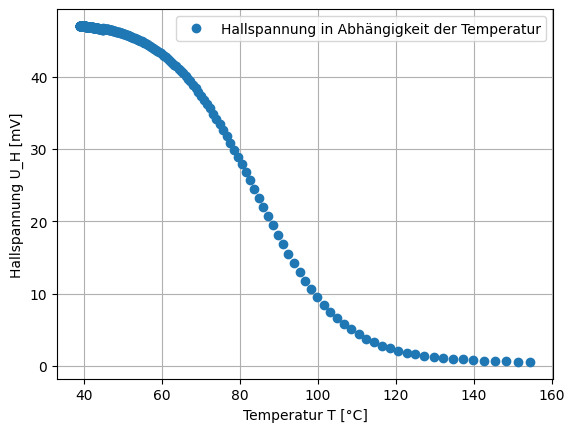

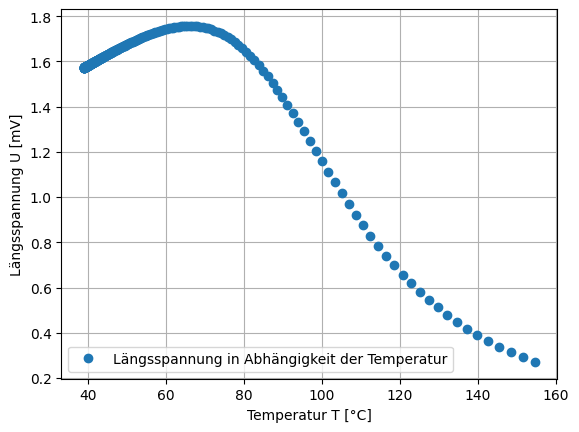

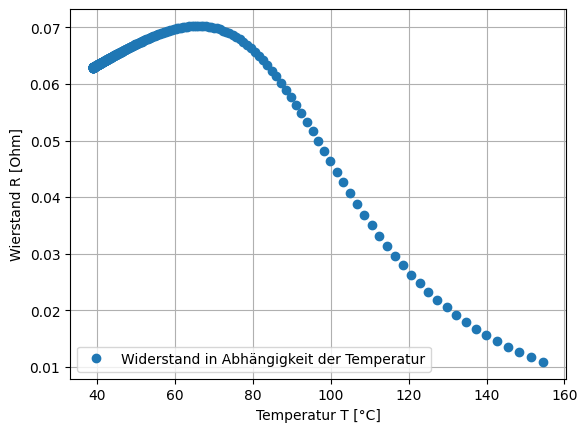

In [20]:
# Temperaturabhängigkeit bei p-Ge (Aufgabe 7)

I_probe = 25                #[mA]

df = pd.read_csv("Do01-PS4.csv", sep=",", decimal=".", engine="python")
T = df["T"].to_numpy()           #Temperatur [°C]
U_H = df["U_H"].to_numpy()         #Hallspannug [mV]
U = df["U"].to_numpy()           #Längsspanung [mV]

#plot U_H gegen T
plt.figure()
plt.plot(T, U_H, 'o', label=f"Hallspannung in Abhängigkeit der Temperatur")
plt.xlabel("Temperatur T [°C]")
plt.ylabel("Hallspannung U_H [mV]")
plt.legend()
plt.grid(True)
plt.show()

#plot U gegen T
plt.figure()
plt.plot(T, U, 'o', label=f"Längsspannung in Abhängigkeit der Temperatur")
plt.xlabel("Temperatur T [°C]")
plt.ylabel("Längsspannung U [mV]")
plt.legend()
plt.grid(True)
plt.show()

#plot Widerstang gegen T
R = U / I_probe

plt.figure()
plt.plot(T, R, 'o', label=f"Widerstand in Abhängigkeit der Temperatur")
plt.xlabel("Temperatur T [°C]")
plt.ylabel("Wierstand R [Ohm]")
plt.legend()
plt.grid(True)
plt.show()
